# Ablation Studies

Systematic analysis of model components for both **BiLSTM** and **Transformer**.

In [1]:
import sys; sys.path.insert(0, '..')
from src import suppress_logs; suppress_logs()

import torch
torch.set_float32_matmul_precision('medium')

from pytorch_lightning import seed_everything
from src.data import GestureDataModule
from src.ablation import AblationRunner, BILSTM_ABLATIONS, TRANSFORMER_ABLATIONS
from src.ablation.config import BILSTM_QUICK, TRANSFORMER_QUICK
from src.visualization import plot_ablation_comparison, print_results_table

/home/marcantoniolopez/Documenti/github/dylem-grid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
QUICK_MODE = False      # Use fewer configurations (faster)
DATA_PATH = None       # Auto-download from HuggingFace
SEED = 42

seed_everything(SEED)

# Select configs based on mode
if QUICK_MODE:
    CONFIGS = {'bilstm': BILSTM_QUICK, 'transformer': TRANSFORMER_QUICK}
    print('Quick mode: fewer configurations')
else:
    CONFIGS = {'bilstm': BILSTM_ABLATIONS, 'transformer': TRANSFORMER_ABLATIONS}
    print('Full mode: all configurations')

for name, cfg in CONFIGS.items():
    print(f'{name.upper()}: {cfg.get_num_configurations()} configs')

Seed set to 42


Full mode: all configurations
BILSTM: 13 configs
TRANSFORMER: 10 configs


In [3]:
dm = GestureDataModule(data_path=DATA_PATH, seed=SEED)

## Run Ablation Studies

In [4]:
all_results = {}

for name, config in CONFIGS.items():
    print(f'\n{"="*60}\n{name.upper()} Ablation Study\n{"="*60}')
    
    runner = AblationRunner(config, dm, {'accelerator': 'auto'})
    results = runner.run(verbose=True)
    all_results[name] = results


BILSTM Ablation Study

Ablation: bilstm_ablation (13 configs)
[1/13] hidden_size=32
    -> 0.9500 ± 0.0177
[2/13] hidden_size=64
    -> 0.9675 ± 0.0127
[3/13] hidden_size=128
    -> 0.9200 ± 0.0789
[4/13] hidden_size=256
    -> 0.9600 ± 0.0094
[5/13] num_layers=1
    -> 0.9600 ± 0.0146
[6/13] num_layers=2
    -> 0.9675 ± 0.0127
[7/13] num_layers=3
    -> 0.9625 ± 0.0158
[8/13] dropout=0.0
    -> 0.9650 ± 0.0146
[9/13] dropout=0.1
    -> 0.9575 ± 0.0257
[10/13] dropout=0.2
    -> 0.9575 ± 0.0170
[11/13] dropout=0.3
    -> 0.9625 ± 0.0079
[12/13] use_attention=True
    -> 0.9675 ± 0.0127
[13/13] use_attention=False
    -> 0.8975 ± 0.0320

ABLATION: bilstm_ablation (13 configs)
Best: hidden_size=64 -> 0.9675 ± 0.0127

TRANSFORMER Ablation Study

Ablation: transformer_ablation (10 configs)
[1/10] d_model=32
    -> 0.8975 ± 0.0242
[2/10] d_model=64
    -> 0.9300 ± 0.0359
[3/10] d_model=128
    -> 0.9575 ± 0.0127
[4/10] num_layers=1
    -> 0.9425 ± 0.0127
[5/10] num_layers=2
    -> 0.9300 ±

## Results Comparison

In [5]:
for name, results in all_results.items():
    results.print_summary()


ABLATION: bilstm_ablation (13 configs)
Best: hidden_size=64 -> 0.9675 ± 0.0127

ABLATION: transformer_ablation (10 configs)
Best: d_model=128 -> 0.9575 ± 0.0127


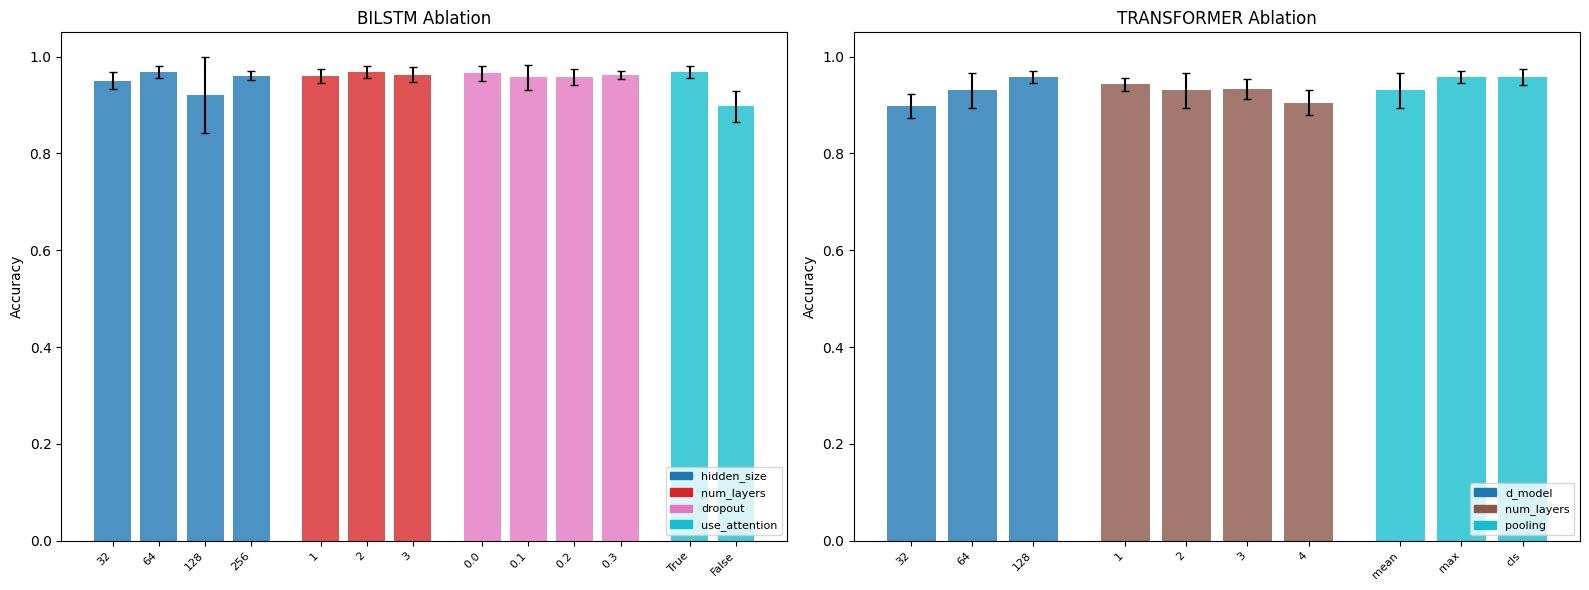

In [6]:
fig = plot_ablation_comparison(all_results)
from pathlib import Path
Path('../plots').mkdir(exist_ok=True)
fig.savefig('../plots/ablation_comparison.png', dpi=150)

## Detailed Results

In [8]:
import pandas as pd

for name, results in all_results.items():
    print(f'\n{name.upper()} Results:')
    df = results.to_dataframe().sort_values('mean_accuracy', ascending=False)
    print(df.to_string(index=False))


BILSTM Results:
        config_name ablation_param ablation_value  mean_accuracy  std_accuracy  mean_f1   std_f1  training_time
     hidden_size=64    hidden_size             64         0.9675      0.012748 0.967438 0.012913     190.036370
 use_attention=True  use_attention           True         0.9675      0.012748 0.967438 0.012913     187.427483
       num_layers=2     num_layers              2         0.9675      0.012748 0.967438 0.012913     186.461106
        dropout=0.0        dropout            0.0         0.9650      0.014577 0.964934 0.014727     183.953551
       num_layers=3     num_layers              3         0.9625      0.015811 0.962633 0.015496     181.608459
        dropout=0.3        dropout            0.3         0.9625      0.007906 0.962375 0.008017     189.447793
       num_layers=1     num_layers              1         0.9600      0.014577 0.959991 0.014422     185.594972
    hidden_size=256    hidden_size            256         0.9600      0.009354 0.960064

## Per-Parameter Analysis

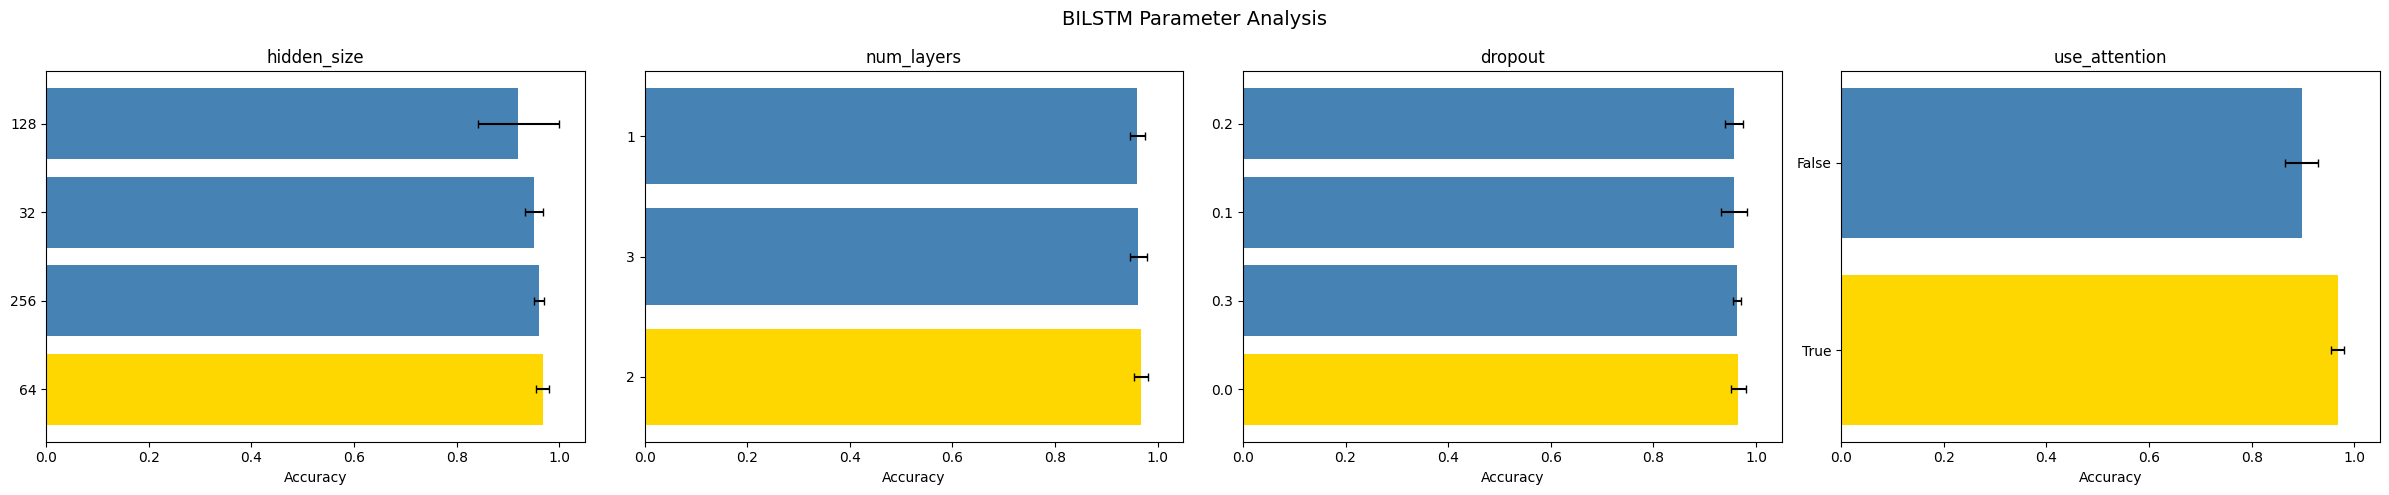

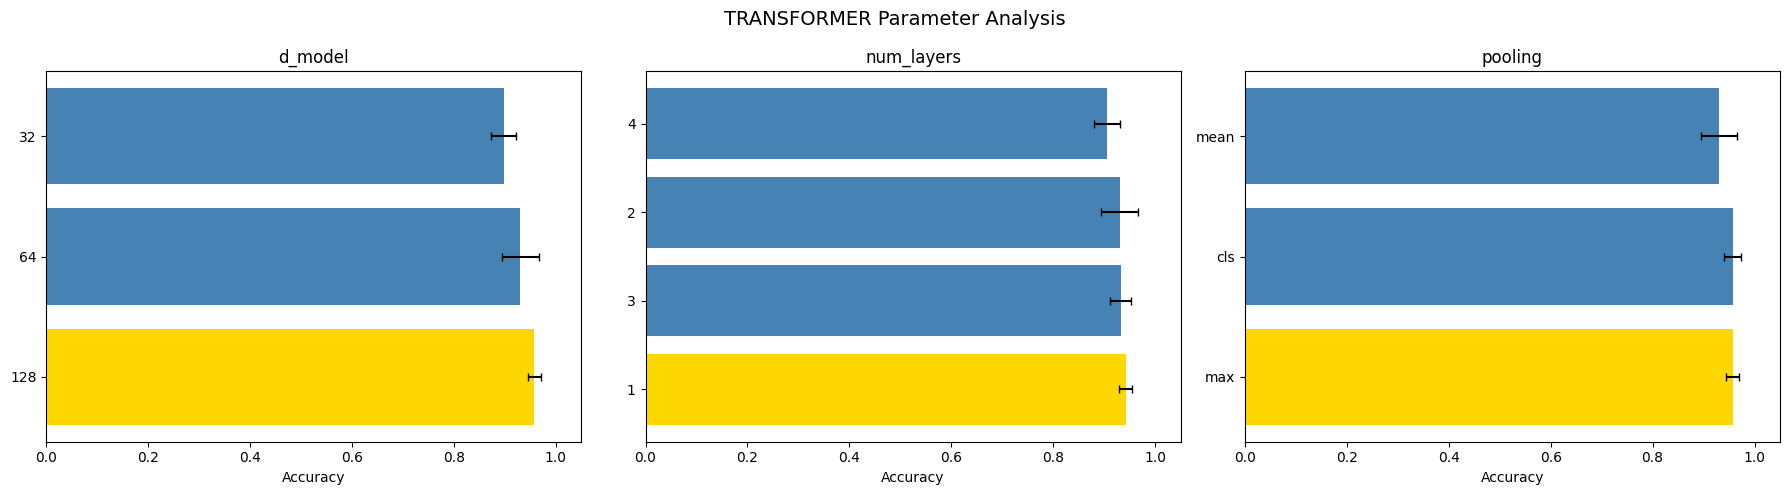

In [9]:
import matplotlib.pyplot as plt

for name, results in all_results.items():
    df = results.to_dataframe()
    params = df['ablation_param'].unique()
    
    fig, axes = plt.subplots(1, len(params), figsize=(6*len(params), 5))
    if len(params) == 1: axes = [axes]
    
    for ax, param in zip(axes, params):
        p = df[df['ablation_param'] == param].sort_values('mean_accuracy', ascending=False)
        colors = ['gold' if i == 0 else 'steelblue' for i in range(len(p))]
        ax.barh(p['ablation_value'].astype(str), p['mean_accuracy'], xerr=p['std_accuracy'], 
                color=colors, capsize=3)
        ax.set_xlabel('Accuracy')
        ax.set_title(f'{param}')
        ax.set_xlim(0, 1.05)
    
    plt.suptitle(f'{name.upper()} Parameter Analysis', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../plots/{name}_ablation_details.png', dpi=150)

## Save Results

In [10]:
from pathlib import Path

save_dir = Path('../results/ablation')
save_dir.mkdir(parents=True, exist_ok=True)

for name, results in all_results.items():
    results.save(str(save_dir / name))
    CONFIGS[name].to_yaml(str(save_dir / name / f'{name}_config.yaml'))

print(f'Results saved to {save_dir}/')

Results saved to ../results/ablation/


## Best Configurations

In [11]:
print('\n' + '='*60 + '\nBEST CONFIGURATIONS\n' + '='*60)
for name, results in all_results.items():
    best = max(results.results, key=lambda r: r.mean_accuracy)
    print(f'\n{name.upper()}:')
    print(f'  Config: {best.config_name}')
    print(f'  Accuracy: {best.mean_accuracy:.4f} ± {best.std_accuracy:.4f}')
    print(f'  F1: {best.mean_f1:.4f}')


BEST CONFIGURATIONS

BILSTM:
  Config: hidden_size=64
  Accuracy: 0.9675 ± 0.0127
  F1: 0.9674

TRANSFORMER:
  Config: d_model=128
  Accuracy: 0.9575 ± 0.0127
  F1: 0.9576
